In [1]:
%mamba install pandas matplotlib

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.944 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.4    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge


# Equity Data Analysis - Top 5 Performers
**Time Frame:** 2021-06-01 to 2021-10-13

### Approach & Assumptions
* **Handling Missing Dates:** I noticed gaps in the data (e.g., ADOB missing data on the exact end date `2021-10-13`, and NETF missing a block of days in early July). I structured my code using `groupby().first()` and `groupby().last()`. This gracefully falls back to the nearest valid trading day, rather than hardcoding exact date lookups which would result in errors.
* **Volume Calculation:** The task requested "30-day average trading volume". I interpreted this as 30 *trading* days, not calendar days. My script takes the tail 30 valid rows for each stock prior to Day Y, dropping `NaN` values so as not to artificially skew the average downwards.
* **Plotting Decision:** Instead of plotting absolute prices, I normalized the starting price of all 5 stocks to `100`. This shows relative performance percentage growth, which accurately matches the table data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import os

# Set plotting style for inline Jupyter display
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading and Cleaning
First, we load the dummy data, convert the date column to datetime objects, and sort the values chronologically.

In [3]:
# Assuming 'prices.csv' is in the same directory as this notebook
file_path = 'prices.csv' 
df = pd.read_csv(file_path)

# Convert dates and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['isin', 'date'])

df.head()

,date,isin,ticker,name,open,high,low,close,volume
9918,2021-01-01,XX0000000010,GENE,General Electric,13.1030,13.1404,12.9088,13.0000,41674476.0
9919,2021-01-04,XX0000000010,GENE,General Electric,12.9959,13.3347,12.4812,12.6537,37481994.0
9920,2021-01-05,XX0000000010,GENE,General Electric,12.5188,13.1222,12.4712,12.9512,86664792.0
9921,2021-01-06,XX0000000010,GENE,General Electric,12.9702,13.0607,12.7702,12.9506,60508959.0
9922,2021-01-07,XX0000000010,GENE,General Electric,13.0054,13.2320,12.9984,13.1993,51484624.0


## 2. Filtering Time Frame & Handling Edge Cases
We isolate the data between `2021-06-01` and `2021-10-13`. 
By grouping by the instrument identifier (ISIN) and selecting the `.first()` and `.last()` records, we automatically bypass missing trading days or `NaN` gaps at the edges of our window.

In [4]:
start_date = pd.to_datetime('2021-06-01')
end_date = pd.to_datetime('2021-10-13')

# Filter for the broad time frame
df_period = df[(df['date'] >= start_date) & (df['date'] <= end_date)].copy()

# Get exact start and end prices safely
df_start = df_period.groupby('isin').first().reset_index()
df_end = df_period.groupby('isin').last().reset_index()

## 3. Calculating Performance
Performance is calculated using the formula: `(Close_End - Close_Start) / Close_Start * 100`

In [12]:
# Merge start and end datasets
# Replace close with adjusted_close to makeup for the reverse stock split
perf_df = pd.merge(
    df_start[['isin', 'ticker', 'name', 'close']], 
    df_end[['isin', 'close']], 
    on='isin', 
    suffixes=('_start', '_end')
)

# Calculate percentage increase
perf_df['performance_%'] = ((perf_df['close_end'] - perf_df['close_start']) / perf_df['close_start']) * 100

# Extract top 5
top_5 = perf_df.nlargest(5, 'performance_%')
top_5_isins = top_5['isin'].tolist()

top_5

,isin,ticker,name,close_start,close_end,performance_%
0,XX0000000010,GENE,General Electric,19.6640,204.5057,940.000509
1,XX0000000028,NETF,Netflix,245.6627,687.8557,180.000057
2,XX0000000036,ADOB,Adobe,424.4101,1026.4742,141.859042
3,XX0000000044,NOKI,Nokia,1.4053,2.9512,110.004981
4,XX0000000051,NVID,NVIDIA,72.1659,133.5070,85.000118


## 4. Calculating 30-Day Average Trading Volume
To get the 30-day average volume on Day Y, we filter the historical data up to Day Y for our top 5 stocks. We drop any `NaN` volumes (like the Netflix halt in July) to ensure we are averaging exactly 30 valid trading sessions.

In [10]:
# Filter data up to end_date for our top 5 stocks
# This is done so that if the dates are reduced and df_period won't have enough data in it and would average, for example 9 days data and present it as 30 days data.
df_top_5_all_history = df[(df['isin'].isin(top_5_isins)) & (df['date'] <= end_date)]

# Drop NaNs, grab the last 30 trading days, and average the volume
vol_30 = (df_top_5_all_history.dropna(subset=['volume'])
                              .groupby('isin')
                              .tail(30)
                              .groupby('isin')['volume']
                              .mean()
                              .reset_index())

vol_30.rename(columns={'volume': '30d_avg_volume'}, inplace=True)

# Merge volume into our top 5 table
final_table = pd.merge(top_5, vol_30, on='isin')

# Formatting for presentation
display_table = final_table[['name', 'isin', 'performance_%', '30d_avg_volume']].copy()

# Force 2 decimal places for percentages (e.g., 940.00% instead of 940.0%)
display_table['performance_%'] = display_table['performance_%'].map('{:.2f}%'.format)

# Add thousands separators for volume (e.g., 8,167,106 instead of 8167106)
display_table['30d_avg_volume'] = display_table['30d_avg_volume'].map('{:,.0f}'.format)

display_table.columns = ['Company Name', 'ISIN', 'Performance', '30-Day Avg Volume']

display_table

,Company Name,ISIN,Performance,30-Day Avg Volume
0,General Electric,XX0000000010,940.00%,"8,167,106"
1,Netflix,XX0000000028,180.00%,"4,974,503"
2,Adobe,XX0000000036,141.86%,"3,105,071"
3,Nokia,XX0000000044,110.00%,"5,131"
4,NVIDIA,XX0000000051,85.00%,"8,284,994"


## 5. Visualizing Relative Performance
To make the chart readable, all stocks are indexed to a starting value of `100`. 
*Observation:* General Electric (GENE) shows a massive, instantaneous price spike in early August accompanied by a sharp drop in trading volume. This strongly suggests a **reverse stock split** rather than organic growth. In a production environment, we would use an `adjusted_close` column to account for this.

*How to fix this:* For example, if General Electric did a 1-for-8 reverse split, the `adjusted_close` column would multiply all historical prices before the split by 8. This ensures that the price chart looks continuous and accurately reflects the true value of an investor's holdings, rather than showing a fake 940% overnight spike.

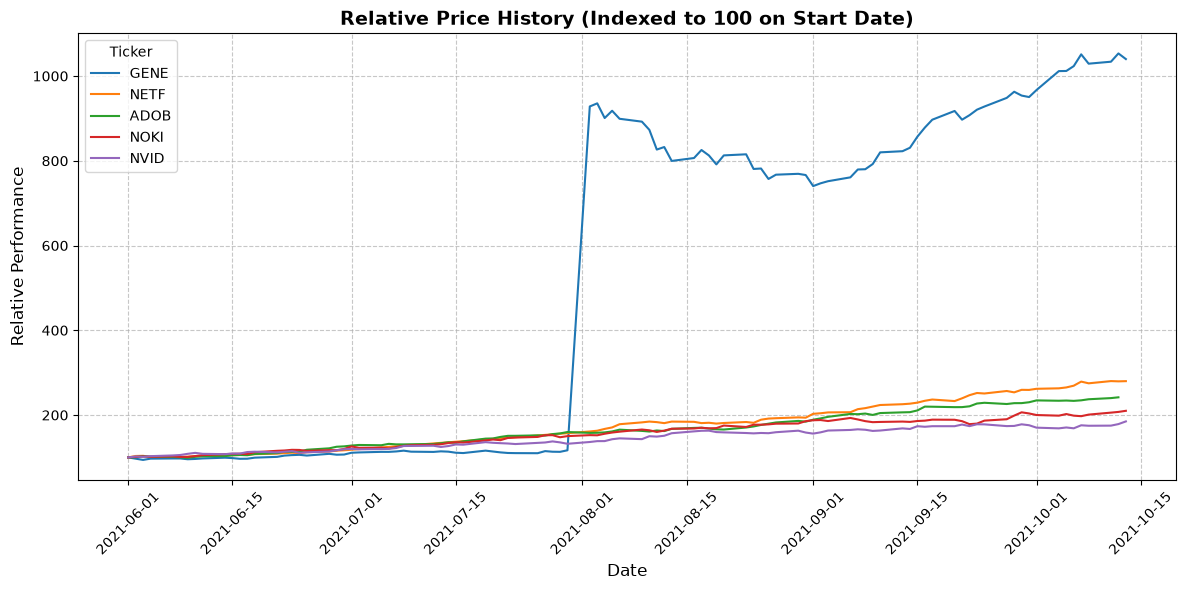

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_df = df_period[df_period['isin'].isin(top_5_isins)]

for ticker in final_table['ticker']:
    # Drop NaNs here to prevent visual gaps in the plotted lines
    ticker_data = plot_df[plot_df['ticker'] == ticker].dropna(subset=['close'])
    normalized_prices = (ticker_data['close'] / ticker_data['close'].iloc[0]) * 100
    ax.plot(ticker_data['date'], normalized_prices, label=f"{ticker}")
    
ax.set_title('Relative Price History (Indexed to 100 on Start Date)', fontweight='bold', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Relative Performance', fontsize=12)
ax.legend(title='Ticker')
ax.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 6. Exporting to PDF
Finally, we fulfill the prompt's requirement to output a PDF containing the table and the plot.

In [8]:
output_pdf = 'top_5_equity_report.pdf'

with PdfPages(output_pdf) as pdf:
    # --- PAGE 1: The Table ---
    fig_table, ax_table = plt.subplots(figsize=(10, 4))
    ax_table.axis('off')
    
    table = ax_table.table(cellText=display_table.values, 
                     colLabels=display_table.columns, 
                     loc='center', 
                     cellLoc='center')
    table.scale(1, 1.8)
    table.set_fontsize(10)
    plt.title('Top 5 Performing Titles (2021-06-01 to 2021-10-13)', pad=20, fontweight='bold')
    pdf.savefig(fig_table, bbox_inches='tight')
    plt.close(fig_table)
    
    # --- PAGE 2: The Chart ---
    # Reusing the figure we generated in Cell 12
    pdf.savefig(fig) 
    
print(f"Successfully generated {output_pdf}")

Successfully generated top_5_equity_report.pdf
